In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from scipy.special import erf, hermite, jvp
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1001)

In [2]:
# In this notebook we showcase the ability of Gaussian Process Regression to estimate
# arbitrary derivatives as well as the first antiderivatives of the underlying function. 
# In order to do so we extend the GaussianProcessRegressor from scikit-learn.

In [3]:
# In our case we fix the kernel of the regression to Constant Kernel * RBF. However other
# kernels would work as well as long as they are integrable/differentiable.

class GPR(GaussianProcessRegressor):
    # Gaussian Process Regressor built on top of sklearn's one. The kernel is
    # fixed to Constant Kernel * RBF where the inital values and bounds can
    # be set through the arguments. All other kwargs can be used analogosly to
    # the base class.
    
    def __init__(self, length_scale=1.0, length_scale_bounds=(1e-5, 1e5),
                 constant_value=1.0, constant_value_bounds=(1e-5,1e5),
                 **kwargs):
        super(GPR, self).__init__(kernel = ConstantKernel(length_scale, length_scale_bounds) 
                                           * RBF(constant_value, constant_value_bounds), 
                                  **kwargs)
        
    def _gaussian(self, x, l=1):
        return np.exp(-1 * x**2 / (2 * l**2))


    def _gaussian_antiderivative(self, x, l=1):
        return np.sqrt(np.pi / 2) * l * erf(x / (np.sqrt(2) * l))                                       


    def _gaussian_derivative(self, x, l, k=1):
        return (-1)**k * (1 / (2 * l**2))**(k / 2) * self._gaussian(x, l=l) * hermite(k)(x / (np.sqrt(2) * l))
        
    def fit(self, X, Y):
        # Fit the GP Regressor for the samples X and targets Y, both of
        # shape (n_samples)
        
        super(GPR, self).fit(X.reshape(-1, 1), Y)
        
    def predict(self, X, k=0):
        # Let the Regressor make its predictions for the values X of shape
        # (n_samples). The output will be of shape (n_samples). 
        # Set k == 1, 2, ... for the k-th derivatives, and k == -1 
        # for the first antiderivative of the underlying function. Higher order
        # antiderivatives are not implemented yet.
        # For k == 0 we get the basic estimate, identical to the one from the 
        # original GaussianProcessRegressor.
        
        c = self.kernel_.k1.constant_value
        l = self.kernel_.k2.length_scale
        A = self.alpha_
        m = self._y_train_mean
        X_diff = X.reshape(-1,1) - self.X_train_.reshape(1,-1)
        
        if k == 0:
            return c * self._gaussian(X_diff, l=l) @ A + m
        
        elif k > 0:
            return c * self._gaussian_derivative(X_diff, l, k=k) @ A

        elif k == -1:
            return c * self._gaussian_antiderivative(X_diff, l) @ A + m * X
        
        else:
            raise Exception('Higher order antiderivatives not implemented')

In [4]:
# To test our Regressor we use the fourth derivative of the Bessel function 
# of the first kind as our underlying ground truth. The choice for this function
# and order is due to its easy avaliablity of derivatives as well as the antiderivative

def f(X, k=0):
    return jvp(7, X, n=k+4)

n_samples = 20 # how many sample points do we take of our function

X_train = np.random.uniform(-15, 15, n_samples)
Y_train = f(X_train)

X_test = np.linspace(-20, 20, 200)

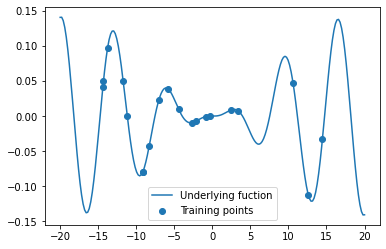

In [5]:
# Let us take a look at the data

Y_test = f(X_test, k=0)

plt.plot(X_test, Y_test, label='Underlying fuction')
plt.scatter(X_train, Y_train, label='Training points')
plt.legend()
plt.show()

In [6]:
# Now we create our Regressor and train it on the provided data

gpr = GPR(normalize_y=True)
gpr.fit(X_train, Y_train)

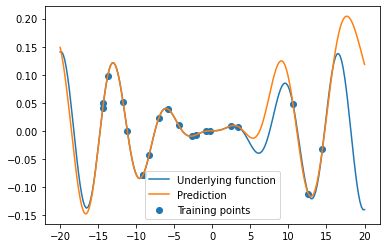

In [7]:
# First we take a look at the prediction of the underlying function

k = 0 # the order of the derivative/antiderivative
Y_predict = gpr.predict(X_test, k=k)
Y_test = f(X_test, k=k)

plt.plot(X_test, Y_test, label='Underlying function')
plt.scatter(X_train, Y_train, label='Training points')
plt.plot(X_test, Y_predict, label='Prediction')

plt.legend()
plt.show()

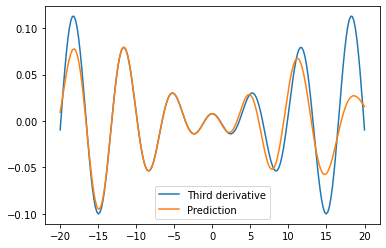

In [8]:
# Then we examine the prediction of its 3rd derivative

k = 3 # the order of the derivative/antiderivative
Y_predict = gpr.predict(X_test, k=k)
Y_test = f(X_test, k=k)

plt.plot(X_test, Y_test, label='Third derivative')
plt.plot(X_test, Y_predict, label='Prediction')
plt.legend()
plt.show()

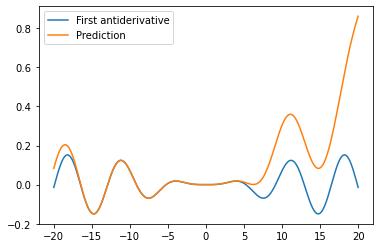

In [9]:
# Lastly we want to see how well the prediction for the antiderivative worked.
# Since those aren't uniquely defined we compute the definite integral from 0 to x.

k = -1 # the order of the derivative/antiderivative
Y_predict = gpr.predict(X_test, k=k) - gpr.predict(np.array(0), k=k)
Y_test = f(X_test, k=k) - f(0, k=k)

plt.plot(X_test, Y_test, label='First antiderivative')
plt.plot(X_test, Y_predict, label='Prediction')
plt.legend()
plt.show()